# VR Blink Signals



|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[1.separate.ipynb](./1.separate.ipynb)|<i>2.vr_blink_signals.ipynb</i>|[3.eeg_blink_signals.ipynb](./3.eeg_blink_signals.ipynb)|

In the previous notebook, we simply separated our files into meaningful divisions in `./data2/`. Now, let's proceed to actually identify a way to detect blinks using VR eye-tracking data.

## Step 0: Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import importlib
from scipy.stats import zscore
from scipy.signal import find_peaks

_EXAMPLE_PARTICIPANT = "P4_Muse2"

## Meta Quest Pro and Blinks

The Meta Quest Pro is uses a vision-based estimator to determine when a person blinks. This is in fact how a majority of VR headsets do eye-tracking. The novelty here is that when a blink gesture is conducted, we should see a specific response in the users' eye data.

Let's look at one of our participants in `./data2/` - specifically, `P4_Muse2`, whose eye data is rather clean for all trials

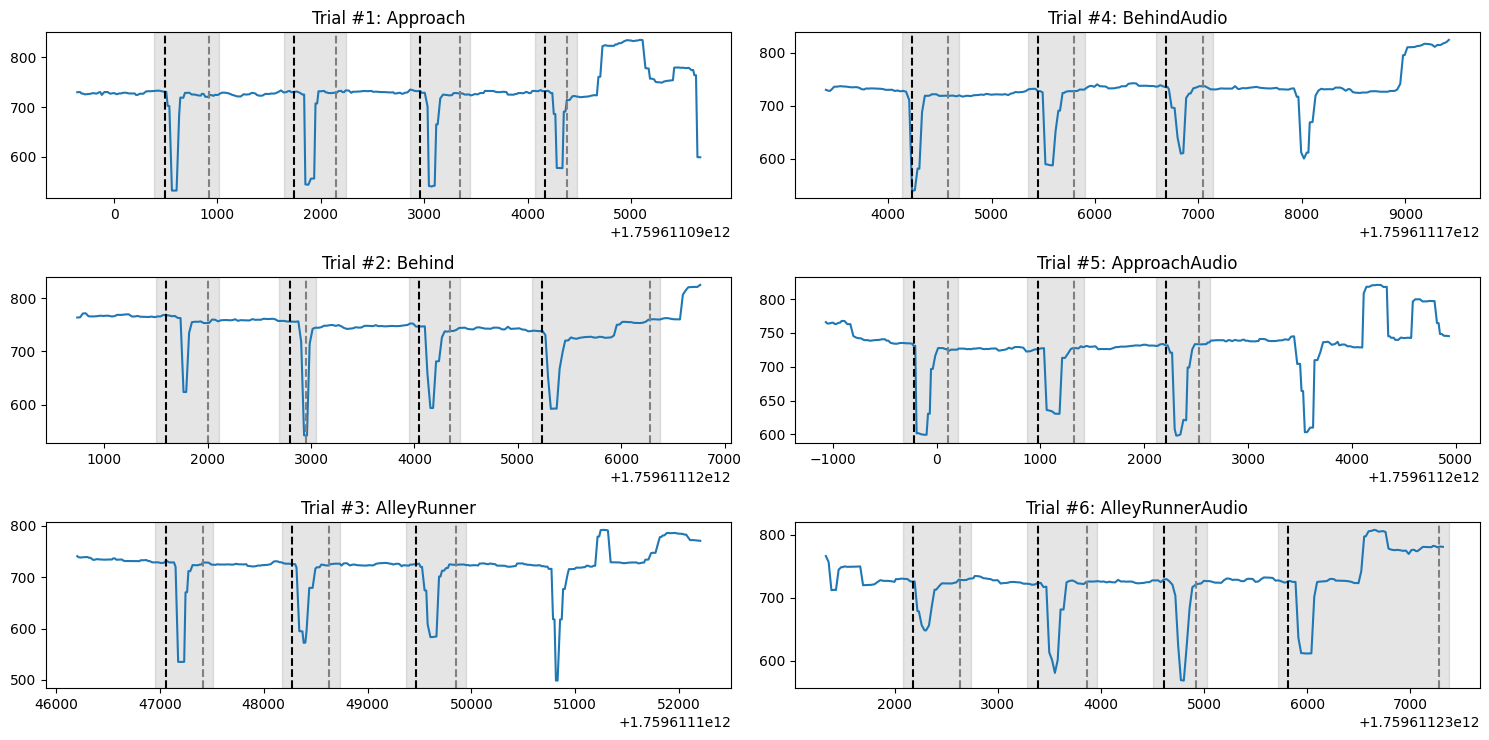

In [17]:
# Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
fig, axes = plt.subplots(3,2,figsize=(15,7.5))

# Read the trial data, which gives us access to the trial numbers
tdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/trials.csv")
for _, row in tdf.iterrows():
    # Read the eye data for each trial
    trial_id = row['trial_id']
    eye = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/eye.csv")
    start_ms = eye['unix_ms'].iloc[0] + 5000
    end_ms = eye['unix_ms'].iloc[-1] - 500
    eye = eye[eye['unix_ms'].between(start_ms, end_ms)]

    # Get the relevant x and y data
    x = eye['unix_ms'].to_list()
    y = eye['gaze_target_screen_pos_y'].to_list()

    # Also get the suspected blink ranges
    brdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/blink_ranges.csv")

    # Get the subplot indices
    row_index = math.floor((trial_id-1) % 3)
    col_index = math.floor((trial_id-1)/ 3)

    # Plot eye data
    ax = axes[row_index][col_index]
    ax.plot(x,y)
    ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")

    # Plot blink ranges
    for _, row in brdf.iterrows():
        ax.axvline(x=row['overlap_unix_ms'], c='black', linestyle='--')
        ax.axvline(x=row['blink_unix_ms'], c='gray', linestyle='--')
        ax.axvspan(xmin=row['start_unix_ms'], xmax=row['end_unix_ms'], color='black', alpha=0.1)

plt.tight_layout()
plt.show()


## Finding Peaks... or Valleys?

The idea here is that we want to be able to find the "valleys" of the eye data. We would normally use a function such as `scipy.signal.find_peaks()` function. However, this function technically finds PEAKS. To achieve the intended affect, we have to literally invert the signal into the negative (by multiplying -1 to each y value).

`find_peaks()` has some parameters we can also explore. Most notably, we have the following:

- `height` (default: `None`): Required height of peaks. Either a number, `None`, an array matching x or a 2-element sequence of the former. The first element is always interpreted as the minimal and the second, if supplied, as the maximal required height.
- `threshold` (default: "None"): Required threshold of peaks, the vertical distance to its neighboring samples. Either a number, `None`, an array matching x or a 2-element sequence of the former. The first element is always interpreted as the minimal and the second, if supplied, as the maximal required threshold. 
- `distance` (default: "None"): Required minimal horizontal distance (>= 1) in samples between neighbouring peaks. Smaller peaks are removed first until the condition is fulfilled for all remaining peaks.
- `prominence` (default: "None"): Required prominence of peaks. Either a number, `None`, an array matching x or a 2-element sequence of the former. The first element is always interpreted as the minimal and the second, if supplied, as the maximal required prominence.
- `width` (default: "None"): Required width of peaks in samples. Either a number, `None`, an array matching x or a 2-element sequence of the former. The first element is always interpreted as the minimal and the second, if supplied, as the maximal required width.
- `wlen` (default: "None"): Used for calculation of the peaks prominences, thus it is only used if one of the arguments prominence or width is given. See argument `wlen` in [peak_prominences](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.peak_prominences.html#scipy.signal.peak_prominences) for a full description of its effects.
- `rel_height` (default: `0.5`): Used for calculation of the peaks width, thus it is only used if width is given. See argument `rel_height` in [peak_widths](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.peak_widths.html#scipy.signal.peak_widths) for a full description of its effects.
- `plateau_size` (default: "None"): Required size of the flat top of peaks in samples. Either a number, `None`, an array matching x or a 2-element sequence of the former. The first element is always interpreted as the minimal and the second, if supplied as the maximal required plateau size.

### Normalizing Scales

One thing we definitely need to do first is _normalize_ our y-axis. This makes the analysis just a bit more balanced. We will be using **z-score normalization** at a per-trial basis.

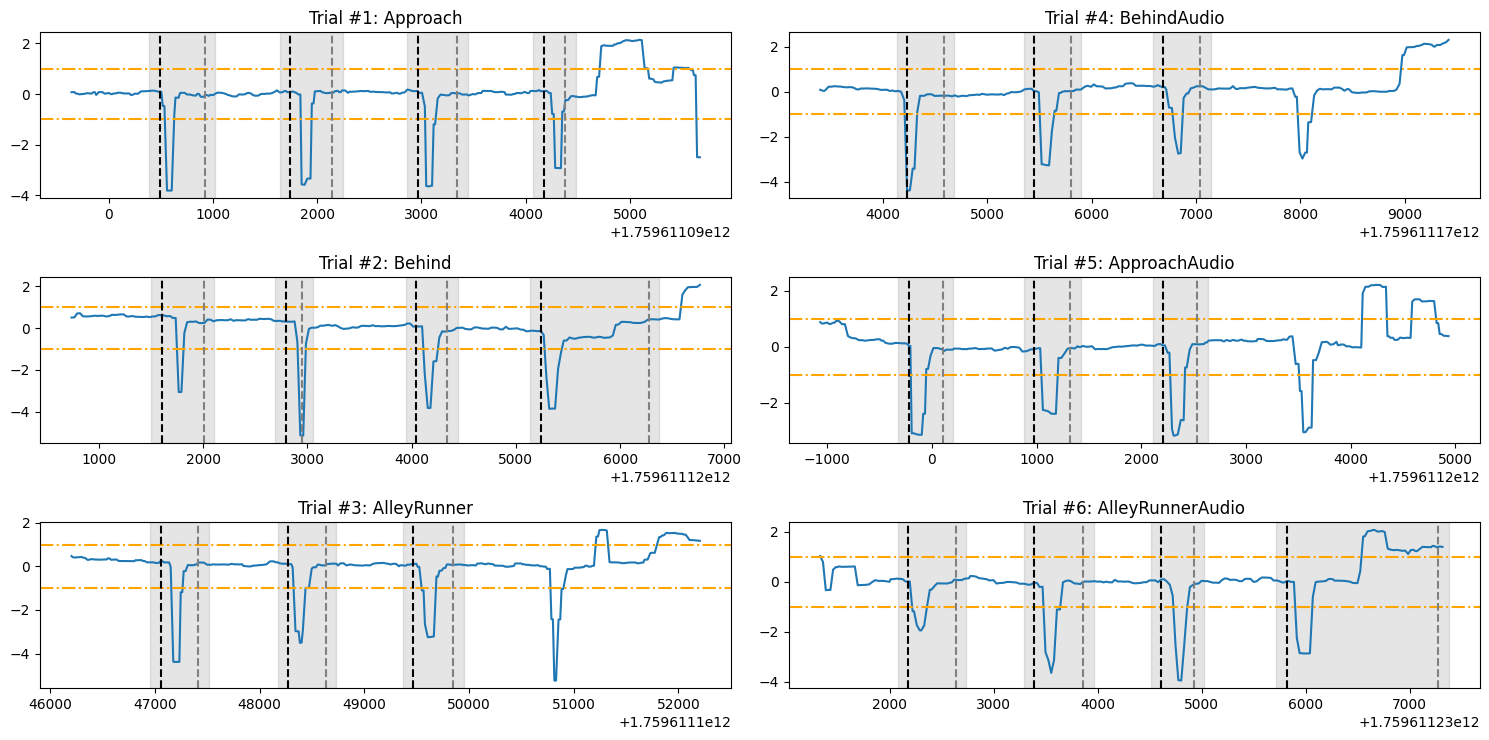

In [18]:

# Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
fig, axes = plt.subplots(3,2,figsize=(15,7.5))

# Read the trial data, which gives us access to the trial numbers
tdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/trials.csv")
for _, row in tdf.iterrows():
    # Read the eye data for each trial
    trial_id = row['trial_id']
    eye = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/eye.csv")
    start_ms = eye['unix_ms'].iloc[0] + 5000
    end_ms = eye['unix_ms'].iloc[-1] - 500
    eye = eye[eye['unix_ms'].between(start_ms, end_ms)]

    # Get the relevant x and y data
    x = eye['unix_ms'].to_list()
    y = eye['gaze_target_screen_pos_y'].to_list()
    z_scores = zscore(y)

    # Also get the suspected blink ranges
    brdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/blink_ranges.csv")

    # Get the subplot indices
    row_index = math.floor((trial_id-1) % 3)
    col_index = math.floor((trial_id-1)/ 3)

    # Plot eye data
    ax = axes[row_index][col_index]
    ax.plot(x, z_scores)
    ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")

    # Plot standard deviation range of -1 and 1
    ax.axhline(y=1, c='orange', linestyle='-.')
    ax.axhline(y=-1, c='orange', linestyle='-.')

    # Plot blink ranges
    for _, row in brdf.iterrows():
        ax.axvline(x=row['overlap_unix_ms'], c='black', linestyle='--')
        ax.axvline(x=row['blink_unix_ms'], c='gray', linestyle='--')
        ax.axvspan(xmin=row['start_unix_ms'], xmax=row['end_unix_ms'], color='black', alpha=0.1)

plt.tight_layout()
plt.show()

However, this won't work in some cases - obseve the failure of detecting peaks and valleys with Trial 6, the first overlap. No values go beyond the standard deviation. To fix this, we need to normalize PER OVERLAP blink.


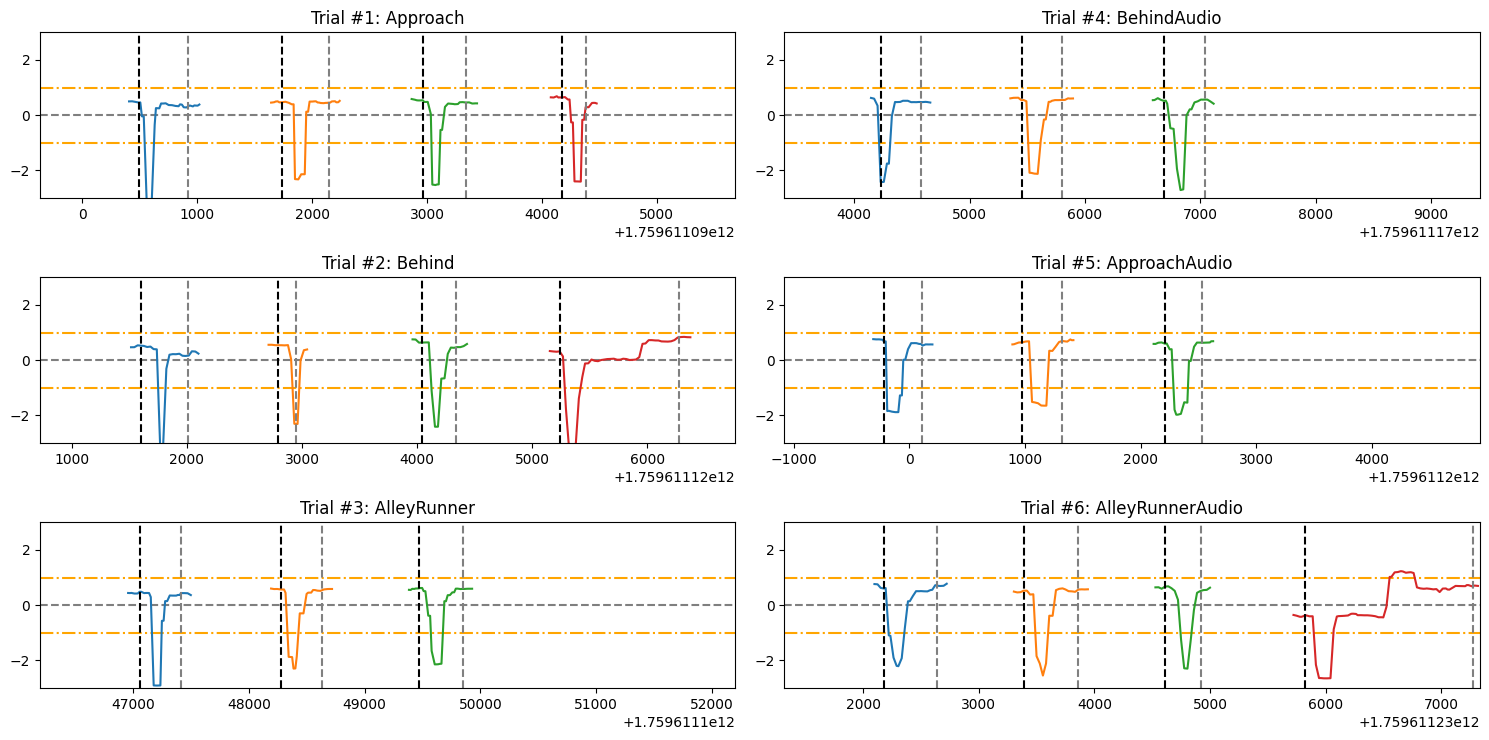

In [19]:
# Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
fig, axes = plt.subplots(3,2,figsize=(15,7.5))

# Read the trial data, which gives us access to the trial numbers
tdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/trials.csv")
for _, row in tdf.iterrows():
    # Read the eye data for each trial
    trial_id = row['trial_id']

    # Read the necessary datasets
    eye = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/eye.csv")
    start_ms = eye['unix_ms'].iloc[0] + 5000
    end_ms = eye['unix_ms'].iloc[-1] - 500
    eye = eye[eye['unix_ms'].between(start_ms, end_ms)]
    brdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/blink_ranges.csv")    

    # Get the subplot indices
    row_index = math.floor((trial_id-1) % 3)
    col_index = math.floor((trial_id-1)/ 3)

    # Plot eye data
    ax = axes[row_index][col_index]
    ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")
    ax.set_xlim(start_ms, end_ms)
    ax.set_ylim(-3, 3)

    # Plot standard deviation range of -1 and 1
    ax.axhline(y=1, c='orange', linestyle='-.')
    ax.axhline(y=-1, c='orange', linestyle='-.')
    ax.axhline(y=0, c='black', linestyle='--', alpha=0.5)

    # Plot blink ranges
    for _, row in brdf.iterrows():
        # Get necessary tim2stamps and 
        overlap_ms = row['overlap_unix_ms']
        blink_ms = row['blink_unix_ms']
        range_start_ms = row['start_unix_ms']
        range_end_ms = row['end_unix_ms']
        _eye = eye[eye['unix_ms'].between(range_start_ms, range_end_ms)]

        # Get the relevant x and y data
        x = _eye['unix_ms'].to_list()
        y = _eye['gaze_target_screen_pos_y'].to_list()
        z_scores = zscore(y)

        # Plot things
        ax.plot(x, z_scores)
        ax.axvline(x=overlap_ms, c='black', linestyle='--')
        ax.axvline(x=blink_ms, c='gray', linestyle='--')

plt.tight_layout()
plt.show()

This is actually a pretty successful implementation. Now we can clearly see that the peaks and valleys go beyond 1 standard deviation from the mean. We would also potentially epxlore a range of -0.5 to 0.5, or -0.75 to 0.75. But we know that this is a viable strategy now.

### Practing with `find_peaks()`

Let's do a setup where we explore the various parameters of `scipy.signals.find_peaks()`.

What is most curious to me is that some of this function's parameters elude a more clear description. What does "Prominence" mean here? Here's what I could find out [source](https://www.askpython.com/python-modules/scipy-signal-find-peaks):

- `height`: We can use this to ignore peaks below some threshold. It can be a single value or a range. For our purposes, a single value should suffice as a minimum threshold.
- `distance`: The minimum _number_ of samples between detected peaks. The idea is that we can use this to remove false multiple detections in wide peaks or closely-spaced noise.
- `prominence`: This is a measure of how much a peak stands out from its surroundings, regardless of the absolute height. This might be a VERY important one to consider.
- `width`: Enforce that only peaks with a certain width (at half-height) are detected. Useful when you expect broad peaks.

So for example:

```python
# Will find only very prominent peaks
peak_indices, properties = find_peaks(signal, prominence=1)

# Will find peaks with a width of at least 10 samples
peak_indices, properties = find_peaks(signal, width=10)
```

We should acknowledge that the `properties` that's also returned has some interesting properties:

- `peak_heights`: Height of each peak.
- `left_bases`, `right_bases`: Points where the peak rises from and falls back to the baseline.
- `widths`, `prominences`: Quantitative peak characteristics.

```python
from scipy.signal import peak_widths
widths, width_heights, left_ips, right_ips = peak_widths(signal, peaks, rel_height=0.5)
```

These ones, I couldn't really find a lot on (rather, I just kind of gave up trying to understand):

- `threshold`: Unknown
- `wlen`: See argument `wlen` in [peak_prominences](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.peak_prominences.html#scipy.signal.peak_prominences) for a full description of its effects.
- `rel_height` See argument `rel_height` in [peak_widths](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.peak_widths.html#scipy.signal.peak_widths) for a full description of its effects.
- `plateau_size` Required size of the flat top of peaks in samples.


In [20]:
from ipywidgets import interact, FloatSlider, IntSlider

# Read the trial data, which gives us access to the trial numbers
tdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/trials.csv")

# We concat the different trial data together
eyes_list = []
ranges_list = []
range_bounds = {}

for _, row in tdf.iterrows():
    # Read the eye data for each trial
    trial_id = row['trial_id']

    # Read the necessary datasets
    eye = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/eye.csv")
    start_ms = eye['unix_ms'].iloc[0] + 5000
    end_ms = eye['unix_ms'].iloc[-1] - 500
    eye = eye[eye['unix_ms'].between(start_ms, end_ms)]
    brdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/blink_ranges.csv") 

    # Add to the lists
    eye['trial_id'] = trial_id
    brdf['trial_id'] = trial_id
    eyes_list.append(eye)
    ranges_list.append(brdf)
    range_bounds[trial_id] = [start_ms, end_ms]

eyes = pd.concat(eyes_list)
ranges = pd.concat(ranges_list)

# Define an update function that will generate the new plot every time
def update_plot(peak_height=0.5, peak_prominence=1, peak_width=0, valley_height=0.5, valley_prominence=1, valley_width=0):

    # Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
    fig, axes = plt.subplots(3,2,figsize=(15,7.5))

    # Iterate through trials
    for _, row in tdf.iterrows():
        # Read the eye data for each trial
        trial_id = row['trial_id']

        # Read the necessary datasets
        eye = eyes[eyes['trial_id'] == trial_id]
        brdf = ranges[ranges['trial_id'] == trial_id]
        [start_ms, end_ms] = range_bounds[trial_id]

        # Get the subplot indices
        row_index = math.floor((trial_id-1) % 3)
        col_index = math.floor((trial_id-1)/ 3)

        # Plot eye data
        ax = axes[row_index][col_index]
        ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")
        ax.set_xlim(start_ms, end_ms)
        ax.set_ylim(-3, 3)

        # Plot standard deviation range of -1 and 1
        #ax.axhline(y=zscore_bounds[0], c='orange', linestyle='-.')
        ax.axhline(y=peak_height, c='blue', linestyle='-.', alpha=0.5)
        ax.axhline(y=-valley_height, c='red', linestyle='-.', alpha=0.5)
        ax.axhline(y=0, c='black', linestyle='--', alpha=0.5)

        # Plot blink ranges
        for _, row in brdf.iterrows():
            # Get necessary tim2stamps and 
            overlap_ms = row['overlap_unix_ms']
            blink_ms = row['blink_unix_ms']
            range_start_ms = row['start_unix_ms']
            range_end_ms = row['end_unix_ms']
            _eye = eye[eye['unix_ms'].between(range_start_ms, range_end_ms)]

            # Get the relevant x and y data
            x = _eye['unix_ms'].to_list()
            y = _eye['gaze_target_screen_pos_y'].to_list()
            z_scores = zscore(y)

            # Plot things
            ax.plot(x, z_scores)
            ax.axvline(x=overlap_ms, c='black', linestyle='--')
            ax.axvline(x=blink_ms, c='gray', linestyle='--')
            ax.axvspan(xmin=range_start_ms, xmax=range_end_ms, color='gray', alpha=0.1)

            # Find peaks
            peak_indices, peak_properties = find_peaks(z_scores, height=peak_height, width=peak_width, prominence=peak_prominence, plateau_size=True)
            peak_lefts = peak_properties['left_edges']
            peak_x = [x[i] for i in peak_lefts]
            peak_y = [z_scores[i] for i in peak_lefts]
            ax.scatter(peak_x, peak_y, marker='x', c='blue')

            # Find valleys
            inverted_zscores = [z*-1 for z in z_scores]
            valley_indices, valley_properties = find_peaks(inverted_zscores, height=valley_height, width=valley_width, prominence=valley_prominence, plateau_size=True)
            valley_lefts = valley_properties['left_edges']
            valley_x = [x[i] for i in valley_lefts]
            valley_y = [z_scores[i] for i in valley_lefts]
            ax.scatter(valley_x, valley_y, marker='x', c='red')

    plt.tight_layout()
    plt.show()

interact(
    update_plot,
    peak_height = FloatSlider(value=0.5, min=0, max=3, step=0.05, description='Peak Height'),
    peak_prominence = IntSlider(value=1, min=0, max=5, description='Peak Prominence'),
    peak_width = IntSlider(value=0, min=0, max=10, description='Peak Width'),
    valley_height = FloatSlider(value=0.5, min=0, max=3, step=0.05, description='Valley Height'),
    valley_prominence = IntSlider(value=1, min=0, max=5, description='Valley Prominence'),
    valley_width = IntSlider(value=0, min=0, max=10, description='Valley Width')
)

interactive(children=(FloatSlider(value=0.5, description='Peak Height', max=3.0, step=0.05), IntSlider(value=1…

<function __main__.update_plot(peak_height=0.5, peak_prominence=1, peak_width=0, valley_height=0.5, valley_prominence=1, valley_width=0)>

This gives us a pretty good idea of how our order of operations:

1. For each blink range, normalize using z-score normalization
2. Detect both peak and valleys, with the following parameters:
    - `height` = `0.5`
    - `width` = `0`
    - `prominence` = `1`
3. Determine the EARLIEST within each blink range.

There are some **lingering issues**, however. Namely, that in areas that OUGHT to be considered plateaus, sometimes `find_peaks()` cannot find them. This leads to peaks or valleys where the resulting detection ends up being much further along than what's expected (.e.g look at Trial #4, Overlap #1). To solve this, we need a **custom** peak-finding measure.

## A More Robust Peak-Finding Algorithm

There are two possible ways we can approach it:

- Use the _base_ start of each suspected plateau. Though this technically produces a timestamp that's a bit earlier than expected, it's a possible fallback.
- Detect the moment when there's a huge difference between two points. i.e. if a see a plateau (that shouldn't be considered a "plateau" by `find_peaks()`), then we can check when the plateau starts.

Let's go with the second one for now. Let's test two helper functions for this:

In [21]:
def find_ascent_start(signal, peak_idx, rel_thresh=0.1, min_drop=1e-6):
    """
    Walk left from peak_idx until the signal drops below a relative threshold
    of the peak height (peak * (1 - rel_thresh)), OR until the slope indicates
    we're at valley/flat region.
    rel_thresh: fraction of peak height used to define base (0.1 => 10% below peak).
    min_drop: tiny positive value to avoid numerical issues on exact equals.
    """
    peak_val = signal[peak_idx]
    # baseline threshold: stop once value <= threshold
    threshold = peak_val * (1 - rel_thresh)
    i = peak_idx
    # walk left while signal is >= threshold (and within bounds)
    while i > 0 and signal[i-1] >= threshold - min_drop:
        i -= 1
    return i

def peak_starts_by_scan(signal, peaks, rel_thresh=0.1):
    starts = [find_ascent_start(signal, p, rel_thresh=rel_thresh) for p in peaks]
    return np.array(starts)

In [22]:
# Read the trial data, which gives us access to the trial numbers
tdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/trials.csv")

# We concat the different trial data together
eyes_list = []
ranges_list = []
range_bounds = {}

for _, row in tdf.iterrows():
    # Read the eye data for each trial
    trial_id = row['trial_id']

    # Read the necessary datasets
    eye = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/eye.csv")
    start_ms = eye['unix_ms'].iloc[0] + 5000
    end_ms = eye['unix_ms'].iloc[-1] - 500
    eye = eye[eye['unix_ms'].between(start_ms, end_ms)]
    brdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/blink_ranges.csv") 

    # Add to the lists
    eye['trial_id'] = trial_id
    brdf['trial_id'] = trial_id
    eyes_list.append(eye)
    ranges_list.append(brdf)
    range_bounds[trial_id] = [start_ms, end_ms]

eyes = pd.concat(eyes_list)
ranges = pd.concat(ranges_list)

# Define an update function that will generate the new plot every time
def update_plot(peak_height=0.5, peak_prominence=1, peak_width=0, valley_height=0.5, valley_prominence=1, valley_width=0):

    # Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
    fig, axes = plt.subplots(3,2,figsize=(15,7.5))

    # Iterate through trials
    for _, row in tdf.iterrows():
        # Read the eye data for each trial
        trial_id = row['trial_id']

        # Read the necessary datasets
        eye = eyes[eyes['trial_id'] == trial_id]
        brdf = ranges[ranges['trial_id'] == trial_id]
        [start_ms, end_ms] = range_bounds[trial_id]

        # Get the subplot indices
        row_index = math.floor((trial_id-1) % 3)
        col_index = math.floor((trial_id-1)/ 3)

        # Plot eye data
        ax = axes[row_index][col_index]
        ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")
        ax.set_xlim(start_ms, end_ms)
        ax.set_ylim(-3, 3)

        # Plot standard deviation range of -1 and 1
        #ax.axhline(y=zscore_bounds[0], c='orange', linestyle='-.')
        ax.axhline(y=peak_height, c='blue', linestyle='-.', alpha=0.5)
        ax.axhline(y=-valley_height, c='red', linestyle='-.', alpha=0.5)
        ax.axhline(y=0, c='black', linestyle='--', alpha=0.5)

        # Plot blink ranges
        for _, row in brdf.iterrows():
            # Get necessary tim2stamps and 
            overlap_ms = row['overlap_unix_ms']
            blink_ms = row['blink_unix_ms']
            range_start_ms = row['start_unix_ms']
            range_end_ms = row['end_unix_ms']
            _eye = eye[eye['unix_ms'].between(range_start_ms, range_end_ms)]

            # Get the relevant x and y data
            x = _eye['unix_ms'].to_list()
            y = _eye['gaze_target_screen_pos_y'].to_list()
            z_scores = zscore(y)

            # Plot things
            ax.plot(x, z_scores)
            ax.axvline(x=overlap_ms, c='black', linestyle='--')
            ax.axvline(x=blink_ms, c='gray', linestyle='--')
            ax.axvspan(xmin=range_start_ms, xmax=range_end_ms, color='gray', alpha=0.1)

            # Find peaks
            peak_indices, peak_properties = find_peaks(z_scores, height=peak_height, width=peak_width, prominence=peak_prominence, plateau_size=True)
            peak_lefts = peak_properties['left_edges']
            adjusted_peaks = peak_starts_by_scan(z_scores, peak_indices)
            peak_x = [x[i] for i in adjusted_peaks]
            peak_y = [z_scores[i] for i in adjusted_peaks]
            ax.scatter(peak_x, peak_y, marker='x', c='blue')

            # Find valleys
            inverted_zscores = [z*-1 for z in z_scores]
            valley_indices, valley_properties = find_peaks(inverted_zscores, height=valley_height, width=valley_width, prominence=valley_prominence, plateau_size=True)
            valley_lefts = valley_properties['left_edges']
            adjusted_valleys = peak_starts_by_scan(inverted_zscores, valley_indices)
            valley_x = [x[i] for i in adjusted_valleys]
            valley_y = [z_scores[i] for i in adjusted_valleys]
            ax.scatter(valley_x, valley_y, marker='x', c='red')

    plt.tight_layout()
    plt.show()

interact(
    update_plot,
    peak_height = FloatSlider(value=0.5, min=0, max=3, step=0.05, description='Peak Height'),
    peak_prominence = IntSlider(value=1, min=0, max=5, description='Peak Prominence'),
    peak_width = IntSlider(value=0, min=0, max=10, description='Peak Width'),
    valley_height = FloatSlider(value=0.5, min=0, max=3, step=0.05, description='Valley Height'),
    valley_prominence = IntSlider(value=1, min=0, max=5, description='Valley Prominence'),
    valley_width = IntSlider(value=0, min=0, max=10, description='Valley Width')
)

interactive(children=(FloatSlider(value=0.5, description='Peak Height', max=3.0, step=0.05), IntSlider(value=1…

<function __main__.update_plot(peak_height=0.5, peak_prominence=1, peak_width=0, valley_height=0.5, valley_prominence=1, valley_width=0)>

That's looking SO much better! We might want to take advantage of this method over the default `find_peak()` version.

## Testing Robustness

This methodology works only with eye data that clearly delineates how the screen position of the eye changes along the y-axis. How about data that isn't so clean? Let's try looking at P1's data, whose eye data isn't very clean.

In [23]:
# Read the trial data, which gives us access to the trial numbers
tdf = pd.read_csv(f"./data2/P1/trials.csv")

# We concat the different trial data together
eyes_list = []
ranges_list = []
range_bounds = {}

for _, row in tdf.iterrows():
    # Read the eye data for each trial
    trial_id = row['trial_id']

    # Read the necessary datasets
    eye = pd.read_csv(f"./data2/P1/{trial_id}/calibration/eye.csv")
    start_ms = eye['unix_ms'].iloc[0] + 5000
    end_ms = eye['unix_ms'].iloc[-1] - 500
    eye = eye[eye['unix_ms'].between(start_ms, end_ms)]
    brdf = pd.read_csv(f"./data2/P1/{trial_id}/calibration/blink_ranges.csv") 

    # Add to the lists
    eye['trial_id'] = trial_id
    brdf['trial_id'] = trial_id
    eyes_list.append(eye)
    ranges_list.append(brdf)
    range_bounds[trial_id] = [start_ms, end_ms]

eyes = pd.concat(eyes_list)
ranges = pd.concat(ranges_list)

# Define an update function that will generate the new plot every time
def update_plot(peak_height=0.5, peak_prominence=1, peak_width=0, valley_height=0.5, valley_prominence=1, valley_width=0):

    # Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
    fig, axes = plt.subplots(3,2,figsize=(15,7.5))

    # Iterate through trials
    for _, row in tdf.iterrows():
        # Read the eye data for each trial
        trial_id = row['trial_id']

        # Read the necessary datasets
        eye = eyes[eyes['trial_id'] == trial_id]
        brdf = ranges[ranges['trial_id'] == trial_id]
        [start_ms, end_ms] = range_bounds[trial_id]

        # Get the subplot indices
        row_index = math.floor((trial_id-1) % 3)
        col_index = math.floor((trial_id-1)/ 3)

        # Plot eye data
        ax = axes[row_index][col_index]
        ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")
        ax.set_xlim(start_ms, end_ms)
        ax.set_ylim(-5, 5)

        # Plot standard deviation range of -1 and 1
        #ax.axhline(y=zscore_bounds[0], c='orange', linestyle='-.')
        ax.axhline(y=peak_height, c='blue', linestyle='-.', alpha=0.5)
        ax.axhline(y=-valley_height, c='red', linestyle='-.', alpha=0.5)
        ax.axhline(y=0, c='black', linestyle='--', alpha=0.5)

        # Plot blink ranges
        for _, row in brdf.iterrows():
            # Get necessary tim2stamps and 
            overlap_ms = row['overlap_unix_ms']
            blink_ms = row['blink_unix_ms']
            range_start_ms = row['start_unix_ms']
            range_end_ms = row['end_unix_ms']
            _eye = eye[eye['unix_ms'].between(range_start_ms, range_end_ms)]

            # Get the relevant x and y data
            x = _eye['unix_ms'].to_list()
            y = _eye['gaze_target_screen_pos_y'].to_list()
            z_scores = zscore(y)

            # Plot things
            ax.plot(x, z_scores)
            ax.axvline(x=overlap_ms, c='black', linestyle='--')
            ax.axvline(x=blink_ms, c='gray', linestyle='--')
            ax.axvspan(xmin=range_start_ms, xmax=range_end_ms, color='gray', alpha=0.1)

            # Find peaks
            peak_raws, peak_properties = find_peaks(z_scores, height=peak_height, width=peak_width, prominence=peak_prominence, plateau_size=True)
            peak_indices = peak_starts_by_scan(z_scores, peak_raws)
            peak_x = [x[i] for i in peak_indices]
            peak_y = [z_scores[i] for i in peak_indices]
            ax.scatter(peak_x, peak_y, marker='x', c='blue')

            # Find valleys
            inverted_zscores = [z*-1 for z in z_scores]
            valley_raws, valley_properties = find_peaks(inverted_zscores, height=valley_height, width=valley_width, prominence=valley_prominence, plateau_size=True)
            #valley_indices = valley_properties['left_edges']
            valley_indices = peak_starts_by_scan(inverted_zscores, valley_raws)
            valley_x = [x[i] for i in valley_indices]
            valley_y = [z_scores[i] for i in valley_indices]
            ax.scatter(valley_x, valley_y, marker='x', c='red')

    plt.tight_layout()
    plt.show()

interact(
    update_plot,
    peak_height = FloatSlider(value=0.5, min=0, max=3, step=0.05, description='Peak Height'),
    peak_prominence = IntSlider(value=1, min=0, max=5, description='Peak Prominence'),
    peak_width = IntSlider(value=0, min=0, max=10, description='Peak Width'),
    valley_height = FloatSlider(value=0.5, min=0, max=3, step=0.05, description='Valley Height'),
    valley_prominence = IntSlider(value=1, min=0, max=5, description='Valley Prominence'),
    valley_width = IntSlider(value=0, min=0, max=10, description='Valley Width')
)

interactive(children=(FloatSlider(value=0.5, description='Peak Height', max=3.0, step=0.05), IntSlider(value=1…

<function __main__.update_plot(peak_height=0.5, peak_prominence=1, peak_width=0, valley_height=0.5, valley_prominence=1, valley_width=0)>

The data appears to be almost incredibly robust. The modifications we made to the scheme, using the modified peak finding algorithm, is doing a TON of work with adjusting for visible plateaus, with some caveats (i.e.g Trial 3, Overlap 1, where the peak is technically lagging). Nonetheless, I would consider this to be a pretty worthwhile venture.

## 1st-Order Derivatives?

Out of curiosity, how robust is the scheme if we decide to use 1st-order derivatives?

In [24]:
# Read the trial data, which gives us access to the trial numbers
tdf = pd.read_csv(f"./data2/P1/trials.csv")

# We concat the different trial data together
eyes_list = []
ranges_list = []
range_bounds = {}

for _, row in tdf.iterrows():
    # Read the eye data for each trial
    trial_id = row['trial_id']

    # Read the necessary datasets
    eye = pd.read_csv(f"./data2/P1/{trial_id}/calibration/eye.csv")
    start_ms = eye['unix_ms'].iloc[0] + 5000
    end_ms = eye['unix_ms'].iloc[-1] - 500
    eye = eye[eye['unix_ms'].between(start_ms, end_ms)]
    brdf = pd.read_csv(f"./data2/P1/{trial_id}/calibration/blink_ranges.csv") 

    # Add to the lists
    eye['trial_id'] = trial_id
    brdf['trial_id'] = trial_id
    eyes_list.append(eye)
    ranges_list.append(brdf)
    range_bounds[trial_id] = [start_ms, end_ms]

eyes = pd.concat(eyes_list)
ranges = pd.concat(ranges_list)

# Define an update function that will generate the new plot every time
def update_plot(peak_height=0.5, peak_prominence=1, peak_width=0, valley_height=0.5, valley_prominence=1, valley_width=0):

    # Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
    fig, axes = plt.subplots(3,2,figsize=(15,7.5))

    # Iterate through trials
    for _, row in tdf.iterrows():
        # Read the eye data for each trial
        trial_id = row['trial_id']

        # Read the necessary datasets
        eye = eyes[eyes['trial_id'] == trial_id]
        brdf = ranges[ranges['trial_id'] == trial_id]
        [start_ms, end_ms] = range_bounds[trial_id]

        # Get the subplot indices
        row_index = math.floor((trial_id-1) % 3)
        col_index = math.floor((trial_id-1)/ 3)

        # Plot eye data
        ax = axes[row_index][col_index]
        ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")
        ax.set_xlim(start_ms, end_ms)
        ax.set_ylim(-4, 4)

        # Plot standard deviation range of -1 and 1
        #ax.axhline(y=zscore_bounds[0], c='orange', linestyle='-.')
        ax.axhline(y=peak_height, c='blue', linestyle='-.', alpha=0.5)
        ax.axhline(y=-valley_height, c='red', linestyle='-.', alpha=0.5)
        ax.axhline(y=0, c='black', linestyle='--', alpha=0.5)

        # Plot blink ranges
        for _, row in brdf.iterrows():
            # Get necessary tim2stamps and 
            overlap_ms = row['overlap_unix_ms']
            blink_ms = row['blink_unix_ms']
            range_start_ms = row['start_unix_ms']
            range_end_ms = row['end_unix_ms']
            _eye = eye[eye['unix_ms'].between(range_start_ms, range_end_ms)]

            # Get the relevant x and y data
            x = _eye['unix_ms'].to_list()
            y = _eye['gaze_target_screen_pos_y'].to_list()
            yd = np.gradient(y)
            z_scores = zscore(yd)

            # Plot things
            ax.plot(x, z_scores)
            ax.axvline(x=overlap_ms, c='black', linestyle='--')
            ax.axvline(x=blink_ms, c='gray', linestyle='--')
            ax.axvspan(xmin=range_start_ms, xmax=range_end_ms, color='gray', alpha=0.1)

            # Find peaks
            peak_raws, peak_properties = find_peaks(z_scores, height=peak_height, width=peak_width, prominence=peak_prominence, plateau_size=True)
            #peak_indices = peak_properties['left_edges']
            peak_indices = peak_starts_by_scan(z_scores, peak_raws)
            peak_x = [x[i] for i in peak_indices]
            peak_y = [z_scores[i] for i in peak_indices]
            ax.scatter(peak_x, peak_y, marker='x', c='blue')

            # Find valleys
            inverted_zscores = [z*-1 for z in z_scores]
            valley_raws, valley_properties = find_peaks(inverted_zscores, height=valley_height, width=valley_width, prominence=valley_prominence, plateau_size=True)
            # valley_indices = valley_properties['left_edges']
            valley_indices = peak_starts_by_scan(inverted_zscores, valley_raws)
            valley_x = [x[i] for i in valley_indices]
            valley_y = [z_scores[i] for i in valley_indices]
            ax.scatter(valley_x, valley_y, marker='x', c='red')

    plt.tight_layout()
    plt.show()

interact(
    update_plot,
    peak_height = FloatSlider(value=0.5, min=0, max=3, step=0.05, description='Peak Height'),
    peak_prominence = IntSlider(value=1, min=0, max=5, description='Peak Prominence'),
    peak_width = IntSlider(value=0, min=0, max=10, description='Peak Width'),
    valley_height = FloatSlider(value=0.5, min=0, max=3, step=0.05, description='Valley Height'),
    valley_prominence = IntSlider(value=1, min=0, max=5, description='Valley Prominence'),
    valley_width = IntSlider(value=0, min=0, max=10, description='Valley Width')
)

interactive(children=(FloatSlider(value=0.5, description='Peak Height', max=3.0, step=0.05), IntSlider(value=1…

<function __main__.update_plot(peak_height=0.5, peak_prominence=1, peak_width=0, valley_height=0.5, valley_prominence=1, valley_width=0)>

This is an interesting approach, but it produces some issues:

- The 1st-derivative values are able to identify peaks and valleys in overlaps that weren't detectable in the original data. However, the peaks and valleys appear to occur much earlier than expected. This, of course, makes some sense; the derivative detects when the velocity of the signal changes, and at the impetus of when the signal starts to gravitate towards a peak or valley, that velocity will already be at its peak or valley.
- This actually may produce more noisy data than before.

I think, though this is an interesting venture, it's not necessarily the best approach. The simpler approach is to just look at the raw data itself. We may determine false positives or missing peaks and valleys, but that'll be filtered out with more people's data that is collected.

## Final Output: Formalizing Everything

We've done a lot of work in this notebook:

1. Explored `find_peaks()` and its advantages/disadvantages
2. Identified parameters for `find_peaks()` that we can use for our system
3. Created a custom peak-finding algorithm compatible with both valleys and peaks.

Let's combine everything into a list of helper functions. We can call upon these at any time.





Let's create a global helper function, `detect_vr_blinks()`, that returns the earliest peak or valley based on the params provided.
    - 

In [25]:
"""
Copied from above, here for sake of summary!
"""

def find_ascent_start(signal, peak_idx, rel_thresh=0.1, min_drop=1e-6):
    """
    Walk left from peak_idx until the signal drops below a relative threshold
    of the peak height (peak * (1 - rel_thresh)), OR until the slope indicates
    we're at valley/flat region.
    rel_thresh: fraction of peak height used to define base (0.1 => 10% below peak).
    min_drop: tiny positive value to avoid numerical issues on exact equals.
    """
    peak_val = signal[peak_idx]
    # baseline threshold: stop once value <= threshold
    threshold = peak_val * (1 - rel_thresh)
    i = peak_idx
    # walk left while signal is >= threshold (and within bounds)
    while i > 0 and signal[i-1] >= threshold - min_drop:
        i -= 1
    return i

def peak_starts_by_scan(signal, peaks, rel_thresh=0.1):
    starts = [find_ascent_start(signal, p, rel_thresh=rel_thresh) for p in peaks]
    return np.array(starts)

In [26]:
from scipy.stats import zscore
from scipy.signal import find_peaks

def calculate_peaks(
        _X, 
        _Y, 
        peak_height=0.5, 
        peak_prominence=1, 
        peak_width=0, 
        valley_height=0.5, 
        valley_prominence=1, 
        valley_width=0):
    """
    Given `_X` (expected: unix timestamps) and `_Y` (expected: raw eye data of the eye's y-position relative to the screen)...
    Find the peaks and valleys associated with this data. We do not make any assumptions about the data itself.
    Returns: a LIST of peaks and valleys 
    """

    # Step 1: Using `scipy.stats.zscore()`, calculate the z-scores of this data. Get its inversion too.
    z = zscore(_Y)
    inv_z = [v*-1 for v in z]

    # Step 2: initialize empty arrays for these
    peaks = None
    valleys = None
    results = None

    # Step 2: Find peaks via `scipy.signal.find_peaks()`, then by `peak_starts_by_scan()`, then sort them in order, then aggregate
    # 2a. `find_peaks()
    peak_raws, _ = find_peaks(z, height=peak_height, width=peak_width, prominence=peak_prominence, plateau_size=True)
    # CHECK: do we even have detected peaks?
    if len(peak_raws) > 0:
        peak_indices = peak_starts_by_scan(z, peak_raws)
        peak_indices.sort()
        peaks = [{'type':'peak', 'x':_X[i], 'y':z[i]} for i in peak_indices]

    # Step 3: Find valleys via `scipy.signal.find_peaks()` and inverted z-scores, then by `peak_starts_by_scan()`, then sort them in order, then aggregate
    valley_raws, _ = find_peaks(inv_z, height=valley_height, width=valley_width, prominence=valley_prominence, plateau_size=True)
    # CHECK: do we even have detected valleys
    if len(valley_raws) > 0:
        valley_indices = peak_starts_by_scan(inv_z, valley_raws)
        valley_indices.sort()
        valleys = [{'type':'valley', 'x':_X[i], 'y':z[i]} for i in valley_indices]

    # Step 4: Combine them into a singular list
    combined = []
    if peaks is not None: combined.extend(peaks)
    if valleys is not None: combined.extend(valleys)
    
    # Step 5: Sort `combined` such that the peaks and valleys are ordered respective to both peaks and valleys
    # CHECK: do we even have any? Only proceed if we do have something
    if len(combined) > 0: 
        results = sorted(combined, key=lambda v: v['x']) 

    # Step 6: Return our findings
    return results, peaks, valleys

In [27]:
def detect_vr_blinks(
        _PARTICIPANT:str,
        **peak_args):
    
    """
    Given `_PARTICIPANT`, which is the participant's unique ID...
    Find the peaks and valleys associated with this participant's data.
    Returns: a dataframe of all first peaks and valleys in each trial
    """
    
    # Get trials of this participant
    trials = pd.read_csv(f"./data2/{_PARTICIPANT}/trials.csv")
    
    # list of outputs
    all_results = []

    # iterate through trials
    for _, row in trials.iterrows():
        # Read the eye data for each trial
        trial_id = row['trial_id']

        # Read the necessary datasets
        eye = pd.read_csv(f"./data2/{_PARTICIPANT}/{trial_id}/calibration/eye.csv")
        start_ms = eye['unix_ms'].iloc[0] + 5000
        end_ms = eye['unix_ms'].iloc[-1] - 500
        eye = eye[eye['unix_ms'].between(start_ms, end_ms)]
        brdf = pd.read_csv(f"./data2/{_PARTICIPANT}/{trial_id}/calibration/blink_ranges.csv") 

        # Iterate through each blink range
        for _, row in brdf.iterrows():

            # Get necessary timestamps
            overlap_counter = row['overlap_counter']
            range_start_ms = row['start_unix_ms']
            range_end_ms = row['end_unix_ms']
            _eye = eye[eye['unix_ms'].between(range_start_ms, range_end_ms)]

            # Get the relevant x and y data
            x = _eye['unix_ms'].to_list()
            y = _eye['gaze_target_screen_pos_y'].to_list()
            
            # Use `find_peaks()` we've created just above to detect combined peaks
            combined, peaks, valleys = calculate_peaks(x, y, **peak_args)

            # Only contribute to `all_results` if `combined` is not None
            if combined is not None: 
                results = [{'trial_id':trial_id, 'overlap_counter':overlap_counter, **c} for c in combined]
                all_results.extend(results)

    # We'll combine all our results into a single dataframe
    df = pd.DataFrame(all_results)
    df = df.groupby(['trial_id', 'overlap_counter'], group_keys=False).apply(lambda g: g.sort_values('x'))

    # We'll extract the first of each trial and overlap
    first_peaks = df.groupby(['trial_id', 'overlap_counter'], as_index=False).first()

    # return the dfs
    return first_peaks, df

### Where Are These Functions Saved?

These functions are saved in `src/components/blink_handling.py`. You can easily access them by importing them there.

## Testing our Helper Functions

In [28]:
# Let's test this code out
from components import blink_handling
importlib.reload(blink_handling)

first_blinks, detected_peaks = blink_handling.detect_vr_blinks('./data2/', _EXAMPLE_PARTICIPANT)
display(first_blinks)

,trial_id,overlap_counter,type,x,y
0,1,1.0,valley,1759611090560,-3.064746
1,1,2.0,valley,1759611091851,-2.312385
2,1,3.0,valley,1759611093046,-2.509957
3,1,4.0,valley,1759611094283,-2.394597
4,2,1.0,valley,1759611121767,-3.107563
5,2,2.0,valley,1759611122933,-2.301383
6,2,3.0,valley,1759611124155,-2.406951
7,2,4.0,valley,1759611125320,-3.192087
8,3,1.0,valley,1759611147176,-2.902757
9,3,2.0,valley,1759611148385,-2.293418


This is pretty good. Let's try rendering them.

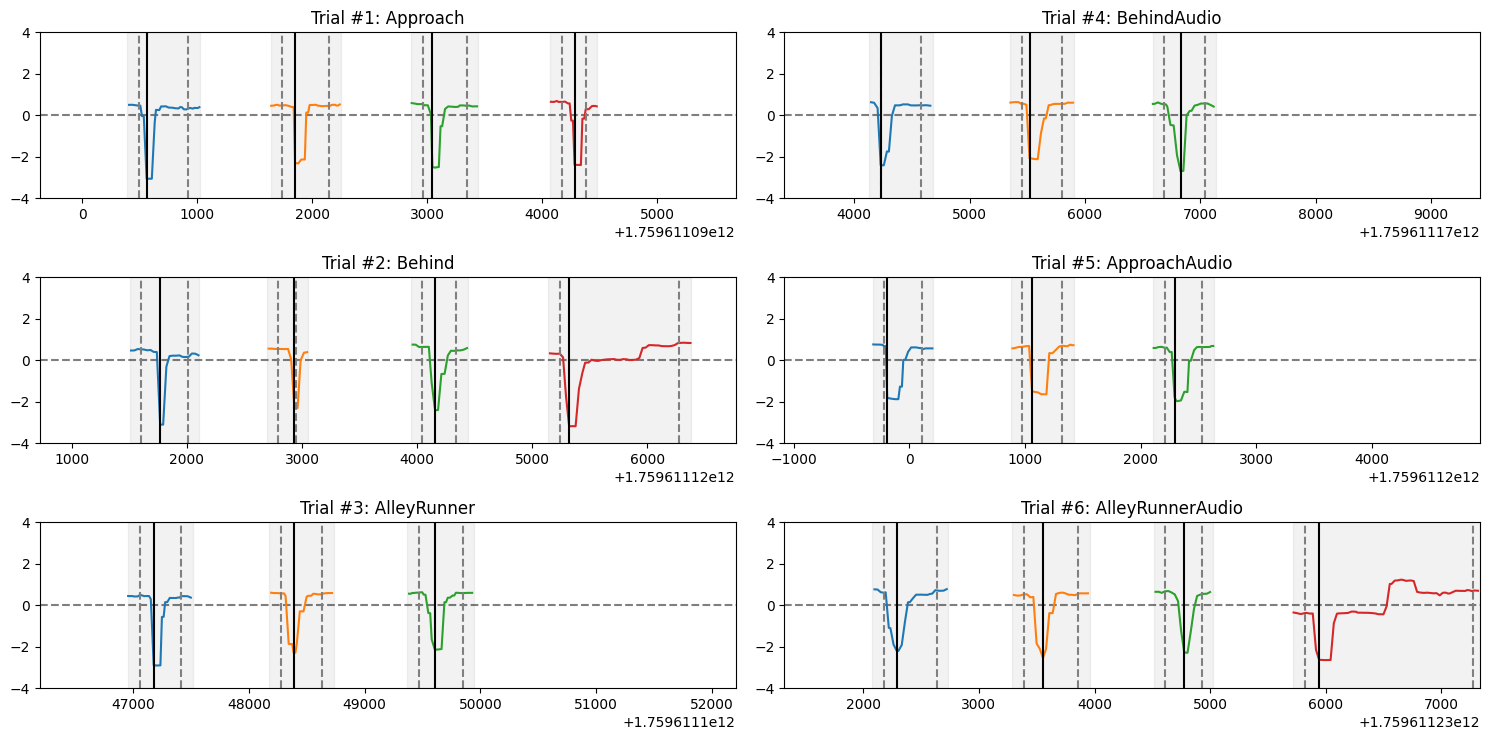

In [29]:
# Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
fig, axes = plt.subplots(3,2,figsize=(15,7.5))

# Read the trial data
tdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/trials.csv")

# Iterate through trials
for _, row in tdf.iterrows():
    # Read the eye data for each trial
    trial_id = row['trial_id']

    # Read the necessary datasets
    eye = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/eye.csv")
    start_ms = eye['unix_ms'].iloc[0] + 5000
    end_ms = eye['unix_ms'].iloc[-1] - 500
    eye = eye[eye['unix_ms'].between(start_ms, end_ms)]
    brdf = pd.read_csv(f"./data2/{_EXAMPLE_PARTICIPANT}/{trial_id}/calibration/blink_ranges.csv") 

    # Get the subplot indices
    row_index = math.floor((trial_id-1) % 3)
    col_index = math.floor((trial_id-1)/ 3)

    # Plot eye data
    ax = axes[row_index][col_index]
    ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")
    ax.set_xlim(start_ms, end_ms)
    ax.set_ylim(-4, 4)
    ax.axhline(y=0, c='black', linestyle='--', alpha=0.5)

    # Plot blink ranges
    for _, row in brdf.iterrows():
        # Get necessary timestamps
        overlap_counter = row['overlap_counter']
        overlap_ms = row['overlap_unix_ms']
        blink_ms = row['blink_unix_ms']
        range_start_ms = row['start_unix_ms']
        range_end_ms = row['end_unix_ms']
        _eye = eye[eye['unix_ms'].between(range_start_ms, range_end_ms)]

        # Get the relevant x and y data
        x = _eye['unix_ms'].to_list()
        y = _eye['gaze_target_screen_pos_y'].to_list()
        z_scores = zscore(y)

        # Plot things
        ax.plot(x, z_scores)
        ax.axvline(x=overlap_ms, c='gray', linestyle='--')
        ax.axvline(x=blink_ms, c='gray', linestyle='--')
        ax.axvspan(xmin=range_start_ms, xmax=range_end_ms, color='gray', alpha=0.1)

        # This time, we pull from `first_blinks`
        estimations = first_blinks[(first_blinks['trial_id']==trial_id) & (first_blinks['overlap_counter']==overlap_counter)]
        for _, estimate in estimations.iterrows():
            # Draw a vertical line to indicate the estimated blink
            ax.axvline(x=estimate['x'], c='black')

plt.tight_layout()
plt.show()


## Saving Results

Let's do the following: for each participant, we do the following:

1. Save the vr blinks inside of `vr_blinks.csv`, inside their respective directories.
2. Save the outputs inside of `./docs/2.vr_blinks/`. We'll save a figure for each participant.

#### Participant P1

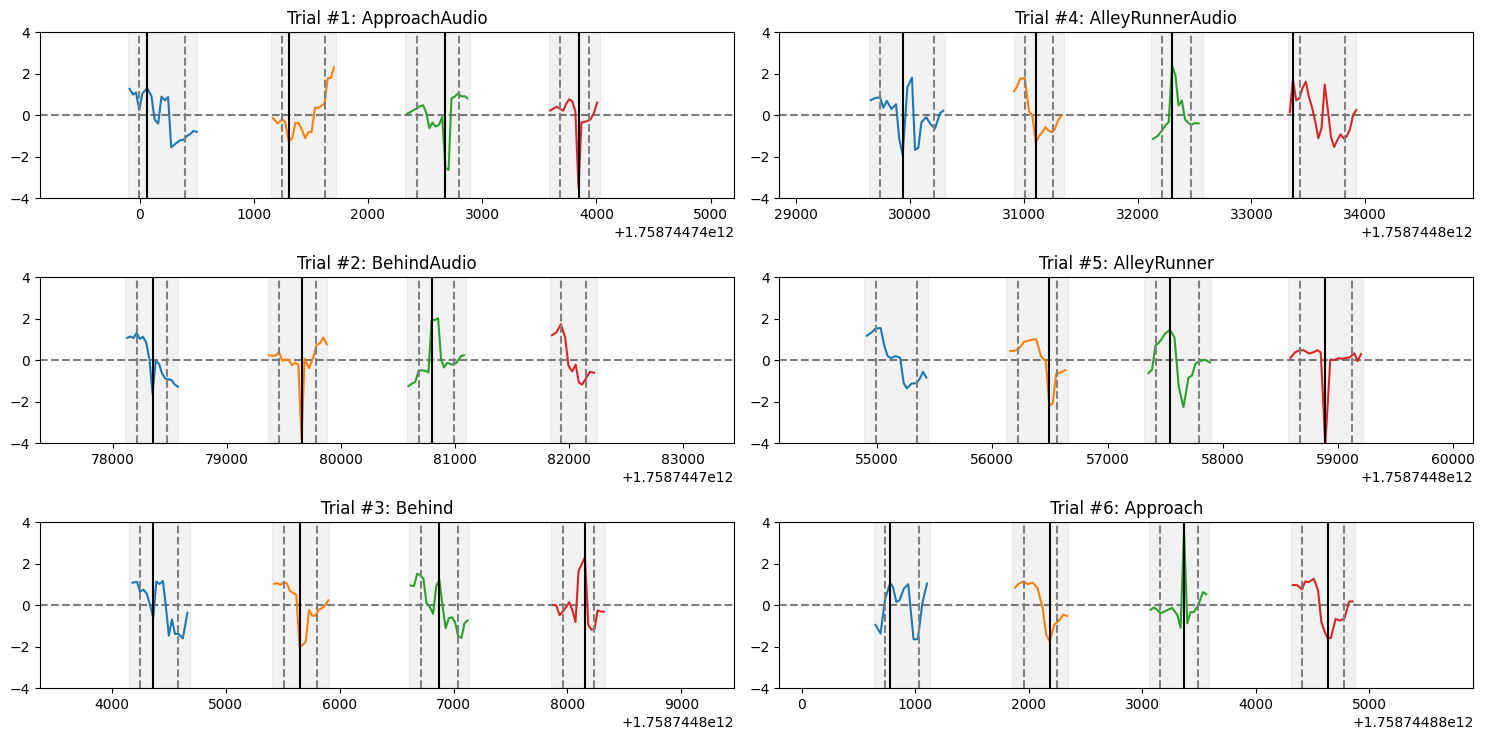

#### Participant PI2

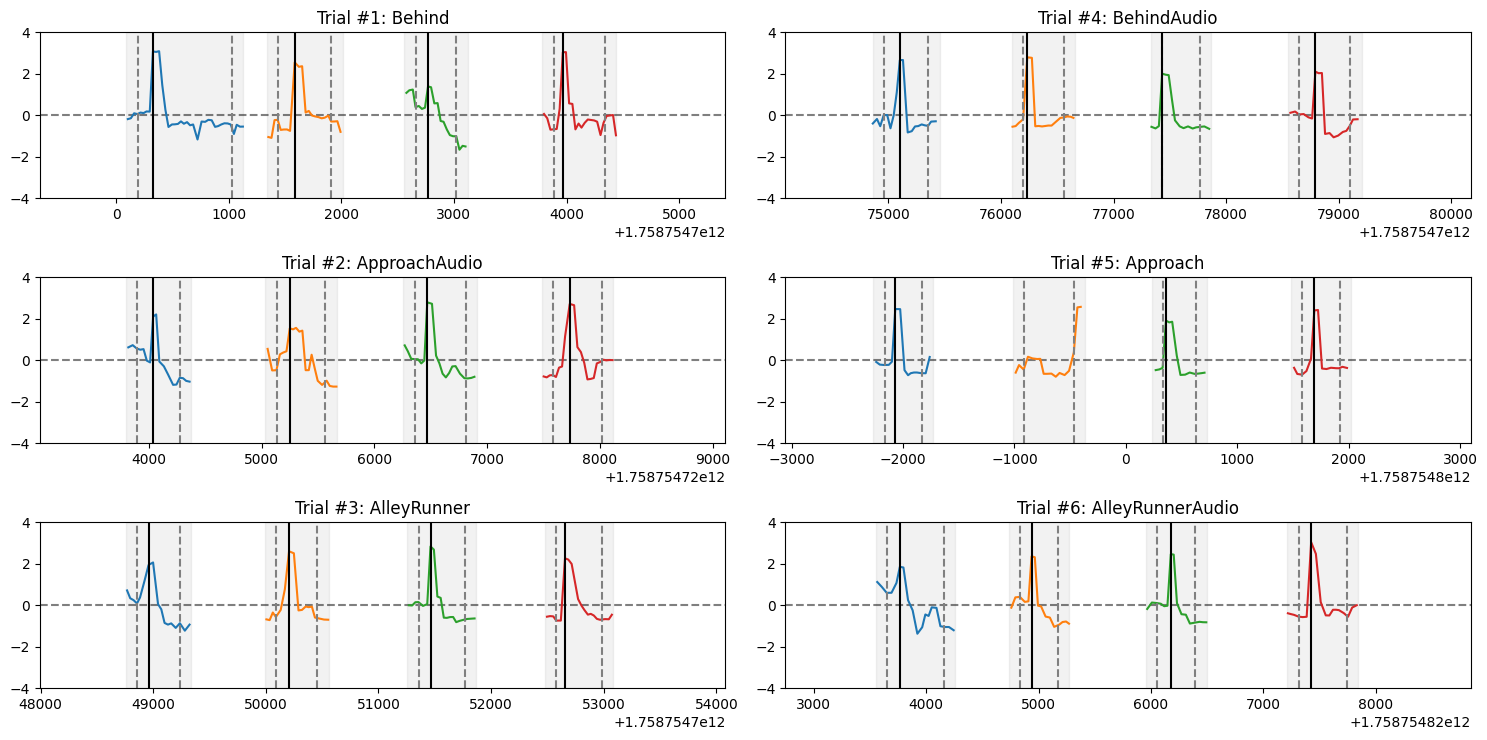

#### Participant P3

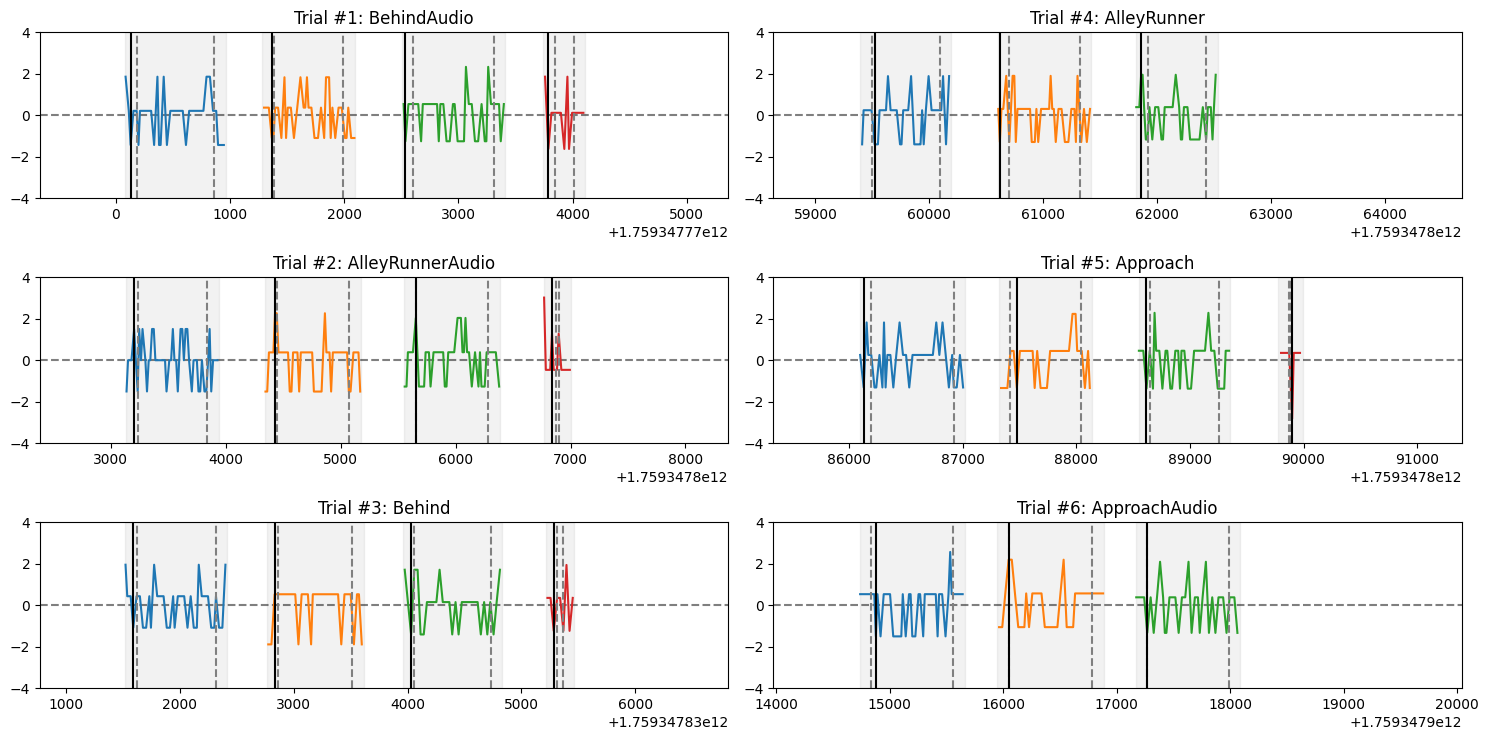

#### Participant P4_Muse2

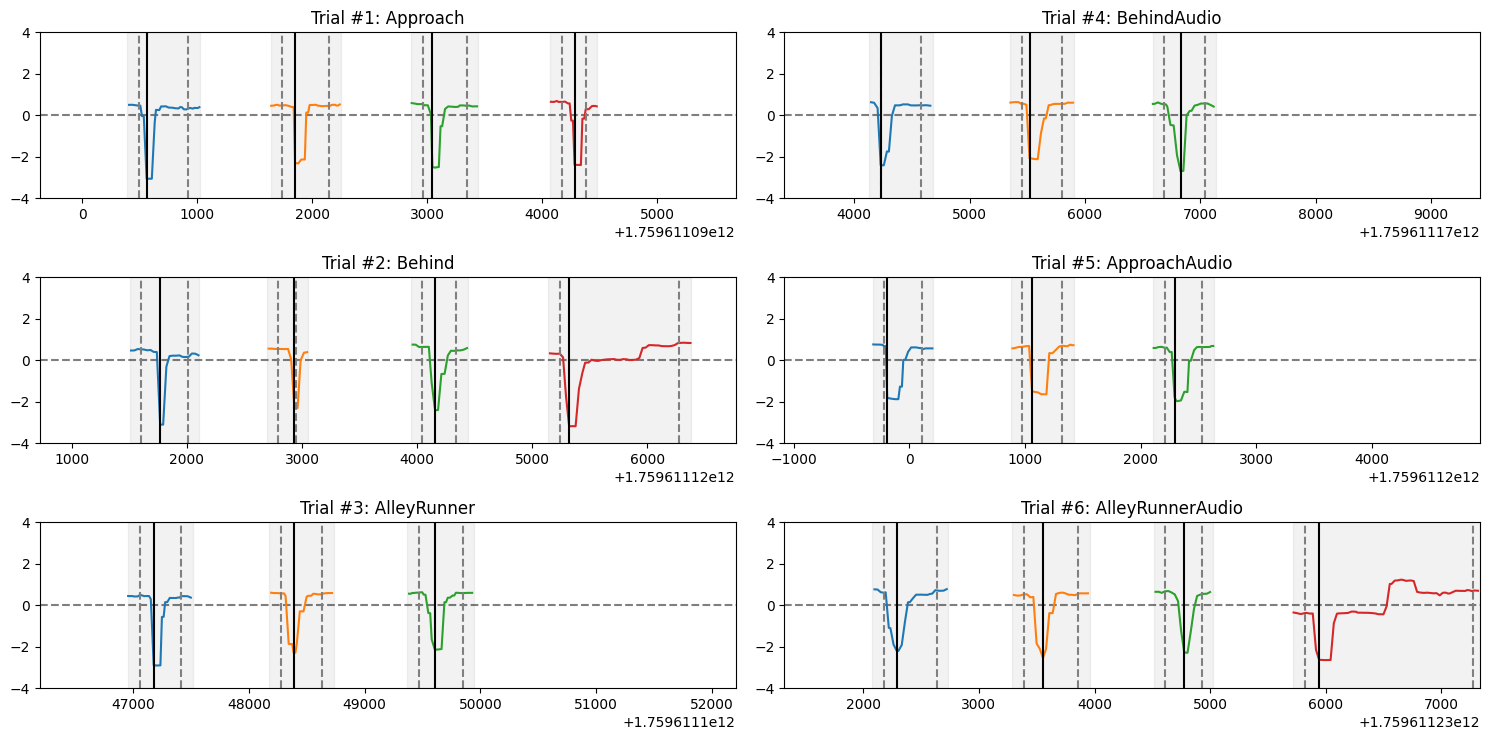

#### Participant P5

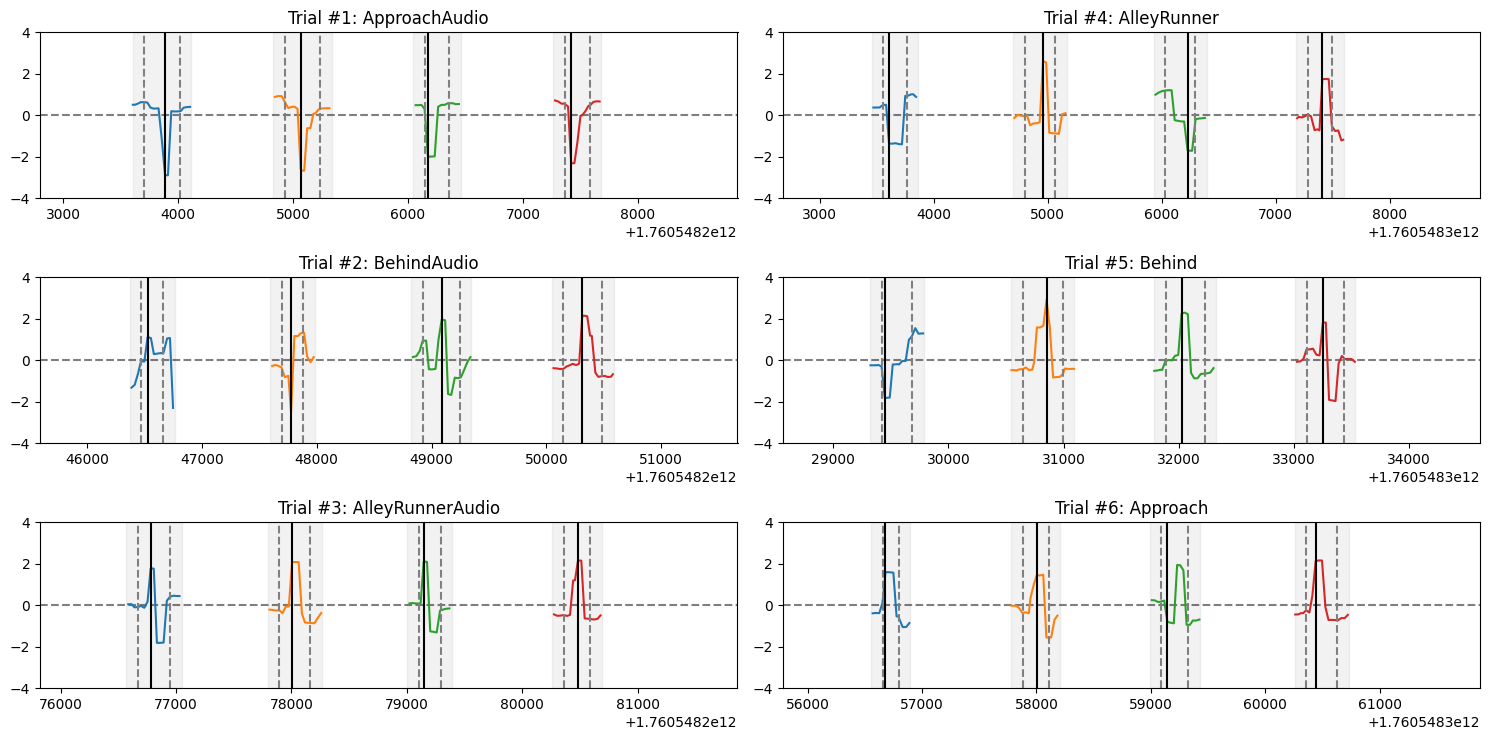

#### Participant P6

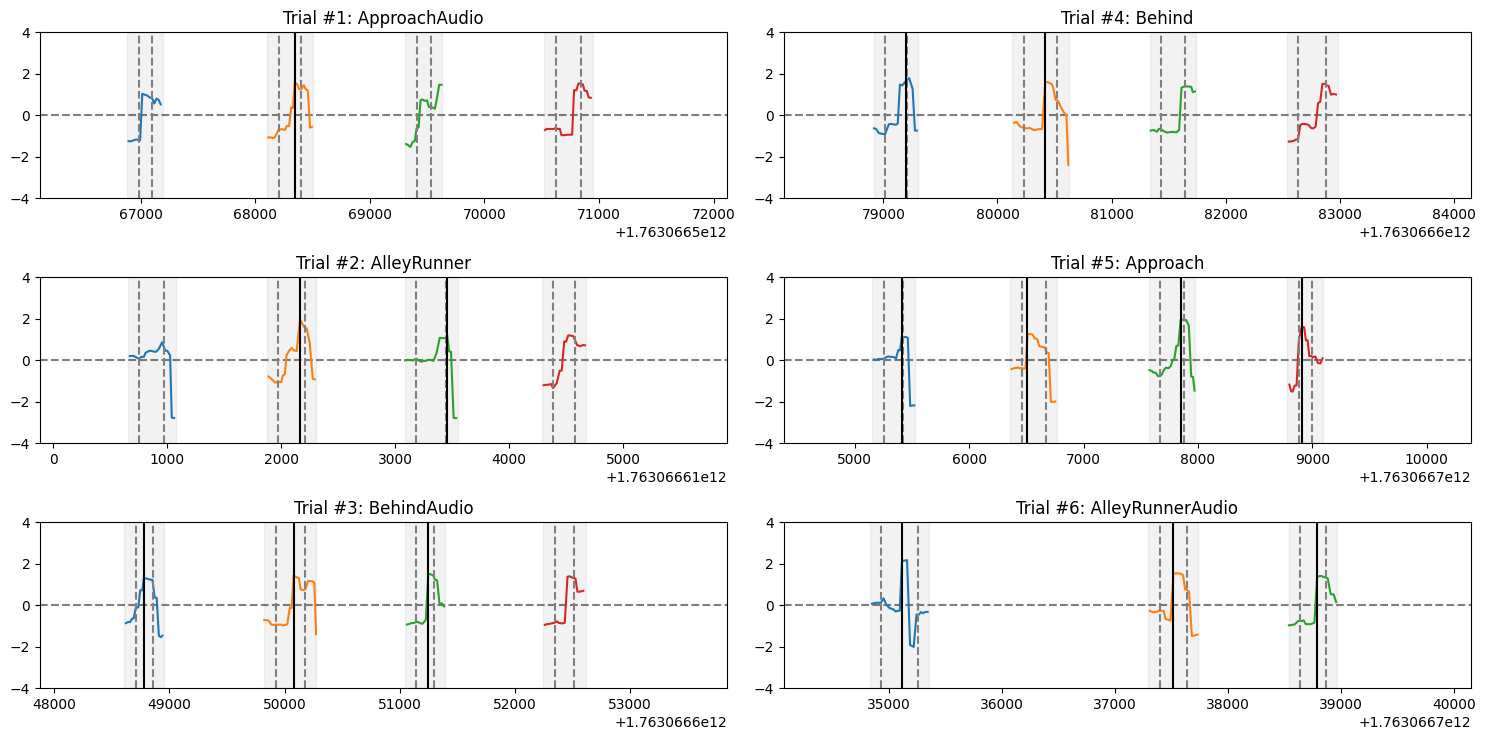

#### Participant P7

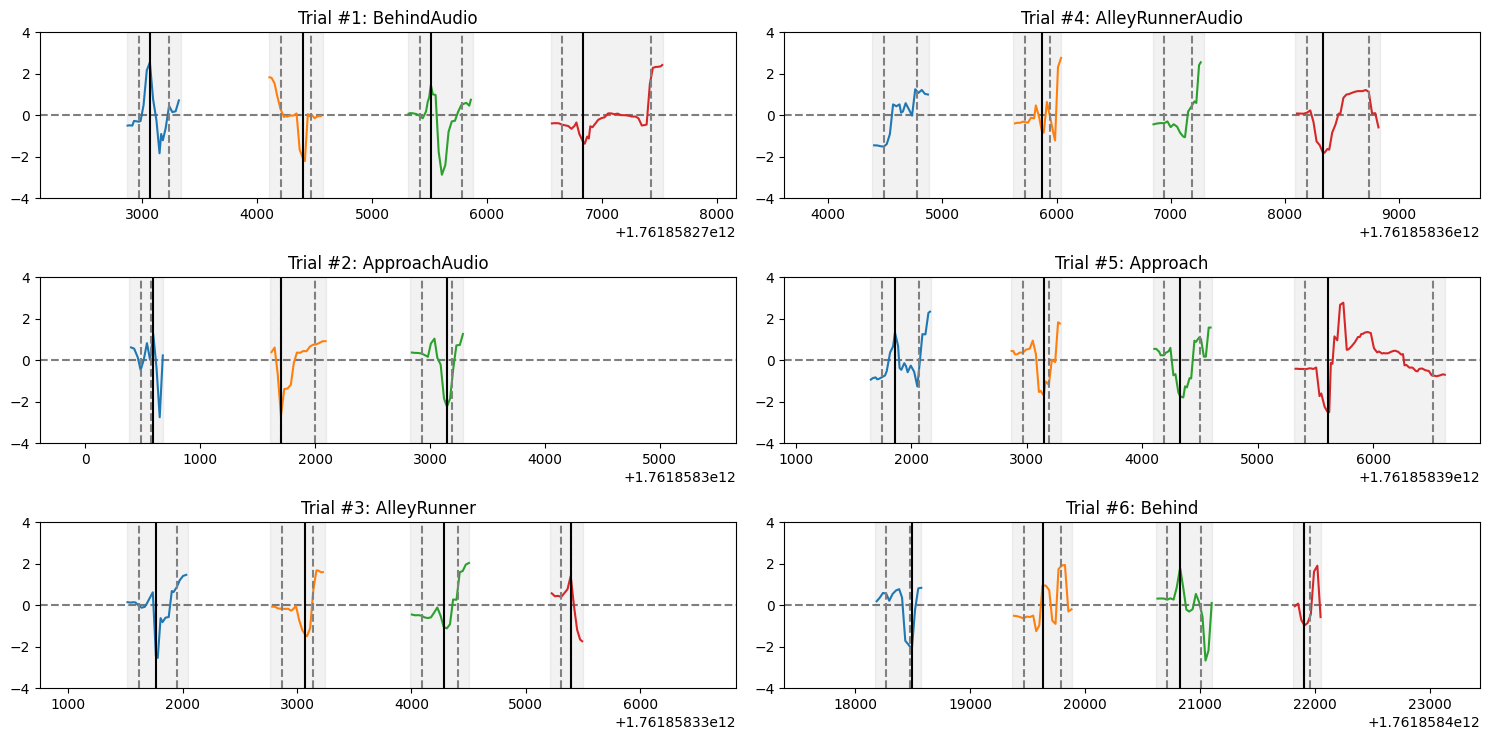

#### Participant P9

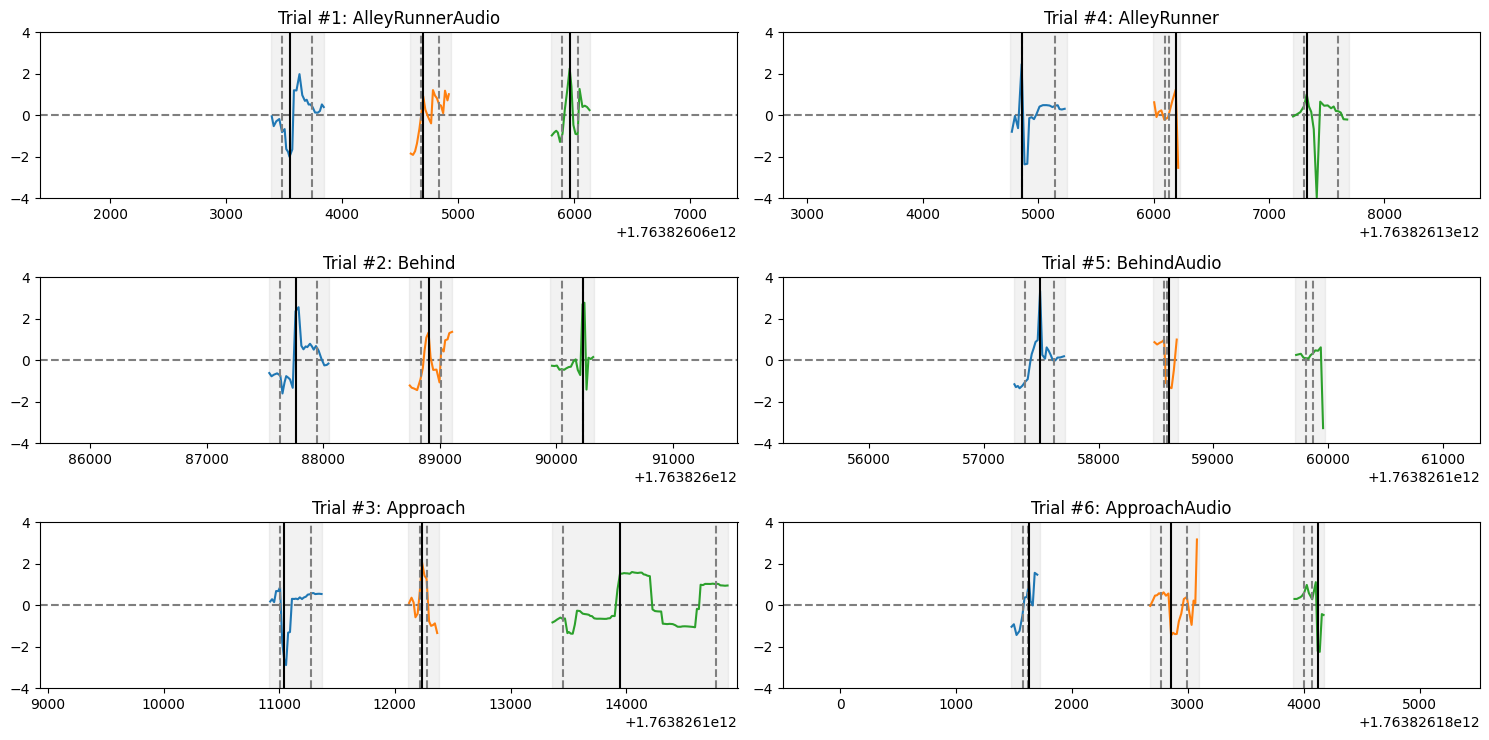

In [30]:
from IPython.display import display, Markdown
import os
from components import file_handling
importlib.reload(file_handling)

_DATA_DIR = './data2/'
_ACTIVE_PARTICIPANTS = [
    'P1',
    'PI2',
    'P3',
    'P4_Muse2',
    'P5',
    'P6',
    'P7',
    'P9'
]

# Create the output directory for all figures
figure_outdir = './docs/2.vr_blink_signals/'
file_handling.mkdirs(figure_outdir)

for p in _ACTIVE_PARTICIPANTS:

    # Get the first estimated blinks, then save it
    pdir = os.path.join(_DATA_DIR, f"{p}/")
    first_blinks, detected_peaks = blink_handling.detect_vr_blinks(_DATA_DIR, p)
    first_blinks.to_csv(os.path.join(pdir, "vr_blinks.csv"), index=False)

    # Now generate the figure
    # Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
    fig, axes = plt.subplots(3,2,figsize=(15,7.5))

    # Read the trial data
    tdf = pd.read_csv(os.path.join(pdir, "trials.csv"))

    # Iterate through trials
    for _, row in tdf.iterrows():
        # Read the eye data for each trial
        trial_id = row['trial_id']
        tdir = os.path.join(pdir, f"{trial_id}/calibration/")

        # Read the necessary datasets
        eye = pd.read_csv(os.path.join(tdir, "eye.csv"))
        start_ms = eye['unix_ms'].iloc[0] + 5000
        end_ms = eye['unix_ms'].iloc[-1] - 500
        eye = eye[eye['unix_ms'].between(start_ms, end_ms)]
        brdf = pd.read_csv(os.path.join(tdir, "blink_ranges.csv")) 

        # Get the subplot indices
        row_index = math.floor((trial_id-1) % 3)
        col_index = math.floor((trial_id-1)/ 3)

        # Plot eye data
        ax = axes[row_index][col_index]
        ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")
        ax.set_xlim(start_ms, end_ms)
        ax.set_ylim(-4, 4)
        ax.axhline(y=0, c='black', linestyle='--', alpha=0.5)

        # Plot blink ranges
        for _, row in brdf.iterrows():
            # Get necessary timestamps
            overlap_counter = row['overlap_counter']
            overlap_ms = row['overlap_unix_ms']
            blink_ms = row['blink_unix_ms']
            range_start_ms = row['start_unix_ms']
            range_end_ms = row['end_unix_ms']
            _eye = eye[eye['unix_ms'].between(range_start_ms, range_end_ms)]

            # Get the relevant x and y data
            x = _eye['unix_ms'].to_list()
            y = _eye['gaze_target_screen_pos_y'].to_list()
            z_scores = zscore(y)

            # Plot things
            ax.plot(x, z_scores)
            ax.axvline(x=overlap_ms, c='gray', linestyle='--')
            ax.axvline(x=blink_ms, c='gray', linestyle='--')
            ax.axvspan(xmin=range_start_ms, xmax=range_end_ms, color='gray', alpha=0.1)

            # This time, we pull from `first_blinks`
            estimations = first_blinks[(first_blinks['trial_id']==trial_id) & (first_blinks['overlap_counter']==overlap_counter)]
            for _, estimate in estimations.iterrows():
                # Draw a vertical line to indicate the estimated blink
                ax.axvline(x=estimate['x'], c='black')

    # Adjust the formatting/layout, and then save it before showing
    plt.tight_layout()
    plt.savefig(os.path.join(figure_outdir, f"{p}.png"), bbox_inches="tight")

    # Show
    display(Markdown(f'#### Participant {p}'))
    plt.show()

## What's Next?

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[1.separate.ipynb](./1.separate.ipynb)|<i>2.vr_blink_signals.ipynb</i>|[3.eeg_blink_signals.ipynb](./3.eeg_blink_signals.ipynb)|

The next notebook is [3.eeg_blink_signals.ipynb](./3.eeg_blink_signals.ipynb), which covers a similar process for determining blinks from EEG data.